### 14장 모델 성능 향상 
* wine 예제

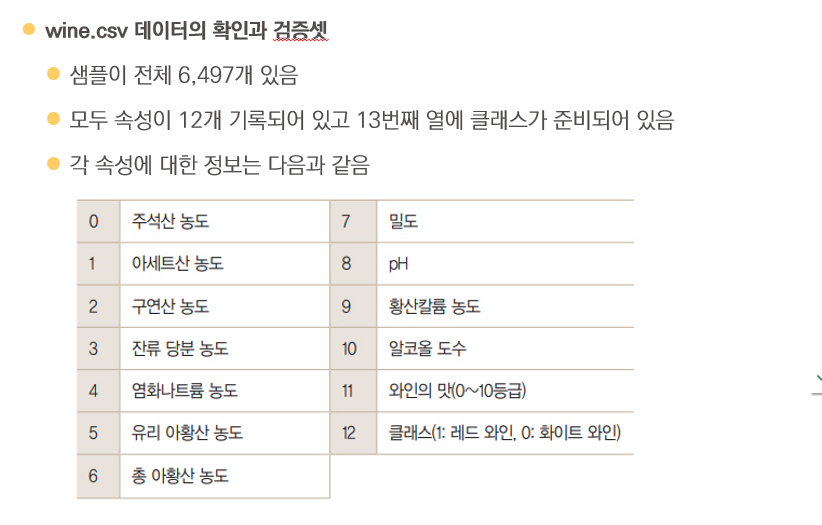

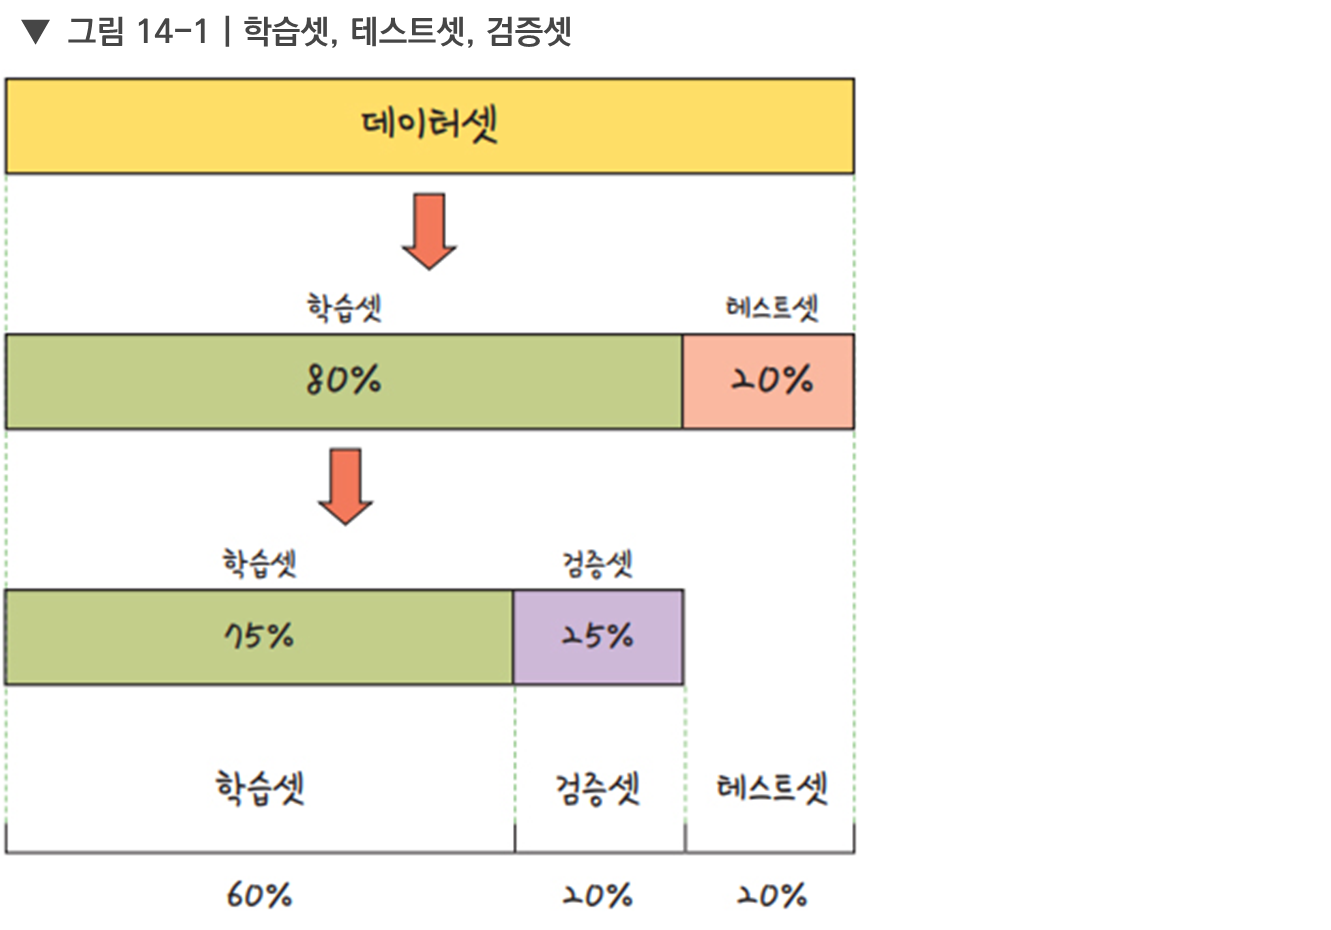

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import pandas as pd

# 데이터를 입력합니다.
df = pd.read_csv('./data/wine.csv', header=None)  # 헤더 데이터가 없는 경우! (자동 컬럼명 부여)

# 데이터를 미리 보겠습니다.
df

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,0
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,0
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,0
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,0


In [2]:
# 와인의 속성을 X로 와인의 분류를 y로 저장합니다.
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X.shape, y.shape

((6497, 12), (6497,))

In [3]:
# #학습셋과 테스트셋으로 나눕니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5197, 12), (1300, 12), (5197,), (1300,))

In [4]:
# 모델의 구조 설정
model = Sequential()
model.add(Dense(24, input_dim=12, activation='relu'))  # 입력 정의
model.add(Dense(30, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # 출력 정의
model.summary() 

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 24)                312       
                                                                 
 dense_1 (Dense)             (None, 30)                750       
                                                                 
 dense_2 (Dense)             (None, 8)                 248       
                                                                 
 dense_3 (Dense)             (None, 1)                 9         
                                                                 
Total params: 1,319
Trainable params: 1,319
Non-trainable params: 0
_________________________________________________________________


In [5]:
X_train.shape

(5197, 12)

In [ ]:
X.shape[0] * 0.8

In [6]:
5197 * 0.75

3897.75

In [7]:
5197 * 0.75 / 200 ## batch size로 나누면 step 수

19.48875

In [8]:
# 모델 컴파일 (loss, optimizer, metrics)  <- 2진 분류...
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 모델 실행 : 검증데이터 비율 지정 0.25
history = model.fit(X_train, y_train, epochs=50, batch_size=200, validation_split=0.25)

## validation_data=(X_test, y_test)
## validation_split=0.25

Epoch 1/50
20/20 [==============================] - 3s 22ms/step - loss: 1.3131 - accuracy: 0.7213 - val_loss: 0.6135 - val_accuracy: 0.7454
Epoch 2/50
20/20 [==============================] - 0s 5ms/step - loss: 0.3228 - accuracy: 0.8825 - val_loss: 0.2462 - val_accuracy: 0.9254
Epoch 3/50
20/20 [==============================] - 0s 4ms/step - loss: 0.2224 - accuracy: 0.9258 - val_loss: 0.2197 - val_accuracy: 0.9338
Epoch 4/50
20/20 [==============================] - 0s 4ms/step - loss: 0.2015 - accuracy: 0.9315 - val_loss: 0.2038 - val_accuracy: 0.9338
Epoch 5/50
20/20 [==============================] - 0s 4ms/step - loss: 0.1890 - accuracy: 0.9343 - val_loss: 0.1903 - val_accuracy: 0.9346
Epoch 6/50
20/20 [==============================] - 0s 5ms/step - loss: 0.1862 - accuracy: 0.9353 - val_loss: 0.1860 - val_accuracy: 0.9354
Epoch 7/50
20/20 [==============================] - 0s 4ms/step - loss: 0.1834 - accuracy: 0.9369 - val_loss: 0.1956 - val_accuracy: 0.9362
Epoch 8/50
20/20 [=

In [9]:
# 테스트 결과 출력 (Test Data Set으로 evaluate)
score = model.evaluate(X_test, y_test)
print('Validation loss=', score[0])
print('Validation accuracy=', score[1])


41/41 [==============================] - 0s 2ms/step - loss: 0.1087 - accuracy: 0.9623
Validation loss= 0.10867178440093994
Validation accuracy= 0.9623076915740967


<Axes: >

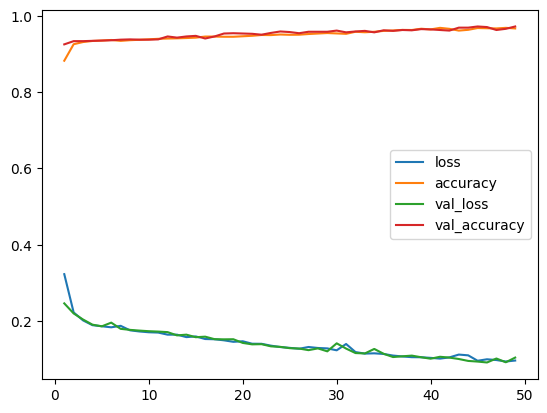

In [10]:
df_result = pd.DataFrame(history.history)
df_result[1:].plot()

## 모델 업데이트

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
import pandas as pd

# 데이터를 입력합니다.
df = pd.read_csv('./data/wine.csv', header=None)
# 와인의 속성을 X로 와인의 분류를 y로 저장합니다.
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# #학습셋과 테스트셋으로 나눕니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# 모델의 구조 설정
model = Sequential()
model.add(Dense(24, input_dim=12, activation='relu'))  # 입력 정의
model.add(Dense(30, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # 출력 정의
model.summary() 

# 모델 컴파일 (loss, optimizer, metrics)  <- 2진 분류...
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 24)                312       
                                                                 
 dense_9 (Dense)             (None, 30)                750       
                                                                 
 dense_10 (Dense)            (None, 8)                 248       
                                                                 
 dense_11 (Dense)            (None, 1)                 9         
                                                                 
Total params: 1,319
Trainable params: 1,319
Non-trainable params: 0
_________________________________________________________________


### 모델의 저장 및 실행

In [15]:
## 모델의 저장 조건 설정 (탐색기로 관찰할 것-폴더내 파일 지우고)
## 매 에포크마다 아래의 파일 이름으로 모델이 저장됨
model_path = './data/model/wine/{epoch:03d}-{val_accuracy:.4f}.keras'
checkpointer = ModelCheckpoint(filepath=model_path, verbose=1)
# checkpointer = ModelCheckpoint(filepath="./data/model/wine_model.keras", verbose=1)
# checkpointer = ModelCheckpoint(filepath=model_path, verbose=1, save_best_only=True)

In [16]:
# 모델 실행
history = model.fit(X_train, y_train, epochs=50, batch_size=200, 
                    verbose=0,    # 모델이 저장되는 것만 로깅하고, 학습 과정은 로깅하지 않음
                    validation_split=0.25,
                    callbacks=[checkpointer])


Epoch 1: saving model to ./data/model/wine\001-0.9085.keras

Epoch 2: saving model to ./data/model/wine\002-0.9285.keras

Epoch 3: saving model to ./data/model/wine\003-0.9354.keras

Epoch 4: saving model to ./data/model/wine\004-0.9331.keras

Epoch 5: saving model to ./data/model/wine\005-0.9338.keras

Epoch 6: saving model to ./data/model/wine\006-0.9362.keras

Epoch 7: saving model to ./data/model/wine\007-0.9400.keras

Epoch 8: saving model to ./data/model/wine\008-0.9385.keras

Epoch 9: saving model to ./data/model/wine\009-0.9400.keras

Epoch 10: saving model to ./data/model/wine\010-0.9415.keras

Epoch 11: saving model to ./data/model/wine\011-0.9423.keras

Epoch 12: saving model to ./data/model/wine\012-0.9400.keras

Epoch 13: saving model to ./data/model/wine\013-0.9415.keras

Epoch 14: saving model to ./data/model/wine\014-0.9423.keras

Epoch 15: saving model to ./data/model/wine\015-0.9431.keras

Epoch 16: saving model to ./data/model/wine\016-0.9423.keras

Epoch 17: saving

In [18]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [19]:
df_history = pd.DataFrame(history.history)
df_history

,loss,accuracy,val_loss,val_accuracy
0,0.616693,0.809597,0.271632,0.908462
1,0.270843,0.911214,0.225171,0.928462
2,0.224079,0.930716,0.191244,0.935385
3,0.204120,0.933025,0.186619,0.933077
4,0.200604,0.931999,0.183592,0.933846
5,0.194983,0.932512,0.180517,0.936154
6,0.189745,0.935335,0.177440,0.940000
7,0.186080,0.936618,0.174104,0.938462
8,0.183722,0.935078,0.173351,0.940000
9,0.180695,0.937901,0.172752,0.941538


<Axes: >

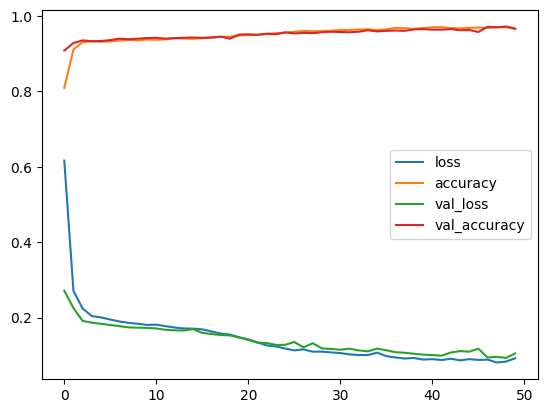

In [20]:
df_history.plot()

<Axes: >

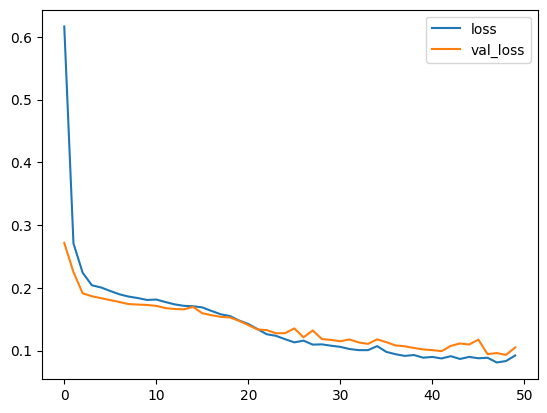

In [21]:
# loss 시각화
import matplotlib.pyplot as plt
df_history[['loss', 'val_loss']].plot()

<Axes: >

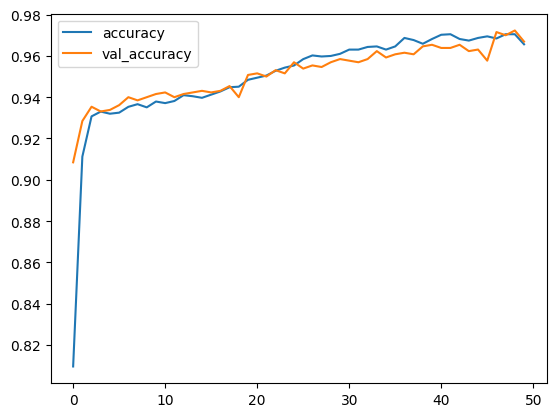

In [22]:
## accuracy 시각화
df_history[['accuracy', 'val_accuracy']].plot()

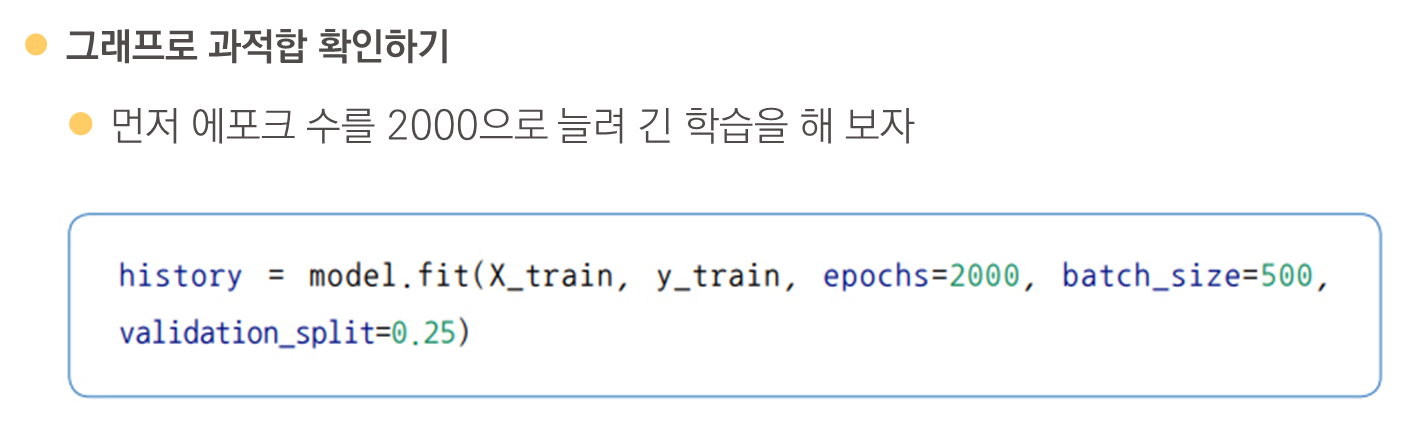

In [23]:
## save_best_only=True로 개선된 모델만 저장
## epochs 2000 -> 시간 오래 걸림 (3분 4초)
## 308번째 epoch에서 val_loss가 최저였음
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
import pandas as pd

# 데이터를 입력합니다.
df = pd.read_csv('./data/wine.csv', header=None)
# 와인의 속성을 X로 와인의 분류를 y로 저장합니다.
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# #학습셋과 테스트셋으로 나눕니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# 모델의 구조 설정
model = Sequential()
model.add(Dense(24, input_dim=12, activation='relu'))  # 입력 정의
model.add(Dense(30, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # 출력 정의
# model.summary() 

# 모델 컴파일 (loss, optimizer, metrics)  <- 2진 분류...
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

## 모델의 저장 조건 설정
model_path = './data/model/wine_model_best.keras'
checkpointer = ModelCheckpoint(filepath=model_path, verbose=1,
                               save_best_only=True)   # 최고 성능 모델만 저장

# 모델 실행 : 과적합이 나오도록 2000번 학습
history = model.fit(X_train, y_train, epochs=2000, batch_size=200, 
                    validation_split=0.25, verbose=0,
                    callbacks=[checkpointer])


Epoch 1: val_loss improved from inf to 0.18768, saving model to ./data/model\wine_model_best.keras

Epoch 2: val_loss improved from 0.18768 to 0.18149, saving model to ./data/model\wine_model_best.keras

Epoch 3: val_loss improved from 0.18149 to 0.16816, saving model to ./data/model\wine_model_best.keras

Epoch 4: val_loss improved from 0.16816 to 0.16527, saving model to ./data/model\wine_model_best.keras

Epoch 5: val_loss did not improve from 0.16527

Epoch 6: val_loss improved from 0.16527 to 0.15950, saving model to ./data/model\wine_model_best.keras

Epoch 7: val_loss did not improve from 0.15950

Epoch 8: val_loss did not improve from 0.15950

Epoch 9: val_loss did not improve from 0.15950

Epoch 10: val_loss did not improve from 0.15950

Epoch 11: val_loss improved from 0.15950 to 0.15396, saving model to ./data/model\wine_model_best.keras

Epoch 12: val_loss did not improve from 0.15396

Epoch 13: val_loss did not improve from 0.15396

Epoch 14: val_loss improved from 0.1539

In [24]:
## 시각화
df_history = pd.DataFrame(history.history)
df_history

,loss,accuracy,val_loss,val_accuracy
0,0.239383,0.915833,0.187676,0.934615
1,0.208249,0.924044,0.181491,0.946154
2,0.202074,0.930459,0.168162,0.946154
3,0.198591,0.930459,0.165273,0.946923
4,0.194926,0.930716,0.168112,0.947692
...,...,...,...,...
1995,0.016154,0.994355,0.058580,0.990000
1996,0.015119,0.994611,0.059730,0.990000
1997,0.015706,0.994355,0.066352,0.990000
1998,0.019709,0.994355,0.060302,0.990769


<Axes: >

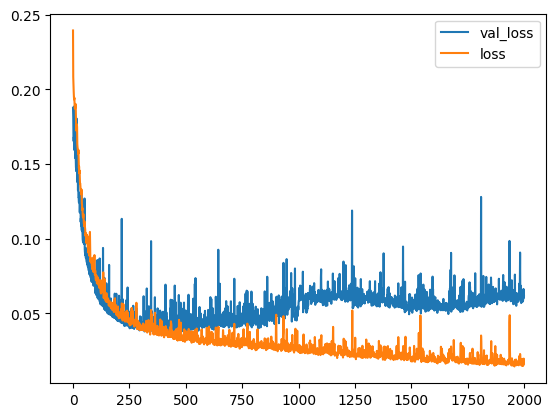

In [25]:
df_history[['val_loss', 'loss']].plot()

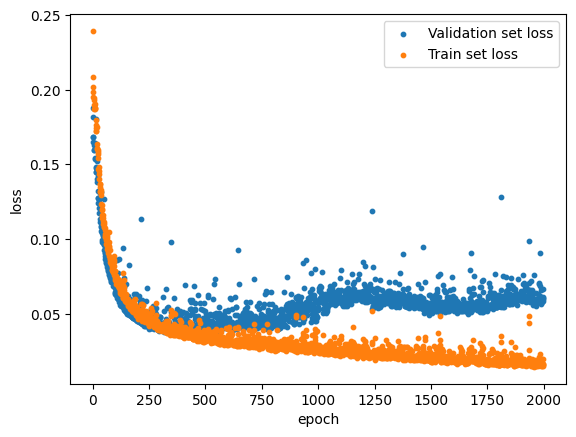

In [26]:
import numpy as np
x_len = np.arange(len(df_history))
plt.scatter(x_len, df_history['val_loss'], s=10, label='Validation set loss')
plt.scatter(x_len, df_history['loss'], s=10, label='Train set loss')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

###  학습 자동 중단 (EarlyStopping)

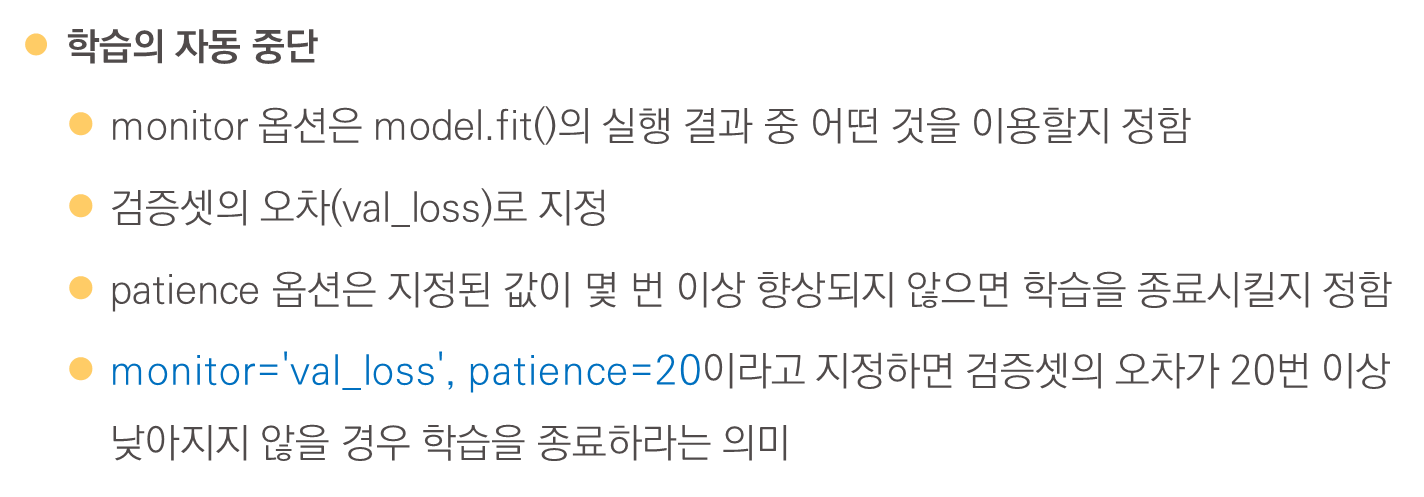

In [27]:
#############################################################
# 파일 자동 저장 : ModelCheckpoint()
# 자동 중단 : EarlyStopping()
#############################################################
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import pandas as pd

# 데이터를 입력합니다.
df = pd.read_csv('./data/wine.csv', header=None)
# 와인의 속성을 X로 와인의 분류를 y로 저장합니다.
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# #학습셋과 테스트셋으로 나눕니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# 모델의 구조 설정
model = Sequential()
model.add(Dense(24, input_dim=12, activation='relu'))  # 입력 정의
model.add(Dense(30, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # 출력 정의
# model.summary() 

# 모델 컴파일 (loss, optimizer, metrics)  <- 2진 분류...
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 학습 자동 중단 callback
early_stopping_callback = EarlyStopping(monitor='val_loss', 
                                        restore_best_weights=True,  # 가장 좋은 모델의 가중치를 복원
                                        patience=10)

## 모델의 저장 조건 설정
# model_path = 'C:/data/model/wine/{epoch:02d}-{val_accuracy:.4f}.hdf5'
## epoch나 정확도 정보를 포함하지 않고, save_best_only=True로 설정하면 최고의 모델 하나만 저장함
model_path = './data/model/wine_best_model.keras'    # 파일명이 변하지 않도록 -> 최종적으로 bestmodel만 저장
checkpointer = ModelCheckpoint(filepath=model_path, verbose=1,
                               save_best_only=True)

# 모델 실행
history = model.fit(X_train, y_train, epochs=2000, batch_size=200, 
                    validation_split=0.25, verbose=0,
                    callbacks=[checkpointer, early_stopping_callback])


Epoch 1: val_loss improved from inf to 0.38801, saving model to ./data/model\wine_best_model.keras

Epoch 2: val_loss improved from 0.38801 to 0.28761, saving model to ./data/model\wine_best_model.keras

Epoch 3: val_loss improved from 0.28761 to 0.24718, saving model to ./data/model\wine_best_model.keras

Epoch 4: val_loss improved from 0.24718 to 0.23040, saving model to ./data/model\wine_best_model.keras

Epoch 5: val_loss improved from 0.23040 to 0.22227, saving model to ./data/model\wine_best_model.keras

Epoch 6: val_loss improved from 0.22227 to 0.21580, saving model to ./data/model\wine_best_model.keras

Epoch 7: val_loss improved from 0.21580 to 0.21097, saving model to ./data/model\wine_best_model.keras

Epoch 8: val_loss improved from 0.21097 to 0.20674, saving model to ./data/model\wine_best_model.keras

Epoch 9: val_loss improved from 0.20674 to 0.20449, saving model to ./data/model\wine_best_model.keras

Epoch 10: val_loss improved from 0.20449 to 0.20341, saving model t

<Axes: >

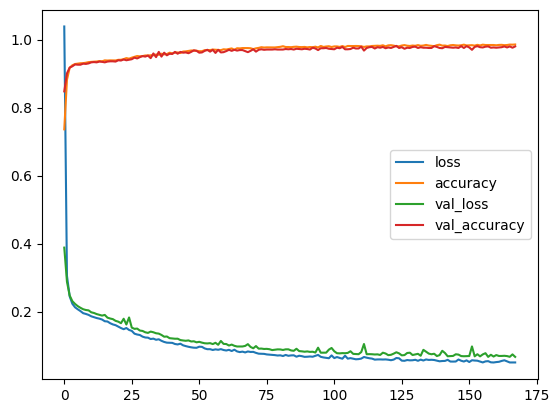

In [28]:
pd.DataFrame(history.history).plot()

In [29]:
score = model.evaluate(X_test, y_test)
print('Test accuracy:', score[1])

41/41 [==============================] - 0s 1ms/step - loss: 0.0687 - accuracy: 0.9815
Test accuracy: 0.9815384745597839


In [30]:
df

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,0
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,0
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,0
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,0


In [ ]:
## 모델 검증
model.evaluate(X_test, y_test)  # [loss, accuracy]

41/41 [==============================] - 0s 3ms/step - loss: 0.0687 - accuracy: 0.9815


[0.06873482465744019, 0.9815384745597839]

In [36]:
## 학습에 사용하지 않은 TEST 데이터로 측정한 모델의 정확도
model.evaluate(X_test, y_test, verbose=0)[1]

0.9815384745597839

In [37]:
## 새로운 X 데이터로 Red / White Wine 여부 판별하기

X_test.shape 

(1300, 12)

In [42]:
# X test 데이터에서 random하게 4개 데이터 추출
new_X = X_test.iloc[[100, 200, 300, 400], :]
new_X

,0,1,2,3,4,5,6,7,8,9,10,11
1475,5.3,0.47,0.11,2.2,0.048,16.0,89.0,0.99182,3.54,0.88,13.566667,7
2165,7.2,0.35,0.34,12.4,0.051,6.0,37.0,0.99440,3.13,0.39,11.500000,6
1522,6.1,0.32,0.25,2.3,0.071,23.0,58.0,0.99633,3.42,0.97,10.600000,5
772,9.5,0.57,0.27,2.3,0.082,23.0,144.0,0.99782,3.27,0.55,9.400000,5


In [ ]:
## 추출된 4개 데이터의 라벨
y_test.iloc[[100, 200, 300, 400]]  # 1: Red wine, 0: White wine

1475    1
2165    0
1522    1
772     1
Name: 12, dtype: int64

In [ ]:
y_hat = model.predict(new_X)    # 예측이 1(Red Wine)일 확률...
y_hat.round(4)

1/1 [==============================] - 0s 43ms/step


array([[0.1923],
       [0.001 ],
       [0.9949],
       [0.7926]], dtype=float32)

In [50]:
y_pred = (y_hat > 0.5).astype(int)
y_pred

array([[0],
       [0],
       [1],
       [1]])